In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os


Sémanticky nebo syntakticky podobná slova mají v tomto prostoru blízké vektory (měřeno např. kosinovou podobností).

Embeddingy zachycují analogie: klasický příklad je $\vec{\text{král}} - \vec{\text{muž}} + \vec{\text{žena}} \approx \vec{\text{královna}}$.

Embeddingy se trénují tak, aby slova vyskytující se v podobných kontextech měla podobné vektory (distributional hypothesis).

In [ ]:
REQUIRED_FILES = [
    '../data/cc.cs.300.vec',
    '../data/cc.en.300.vec',
    'cs-en.0-5000.txt',
    'cs-en.5000-6500.txt',
]

for filename in REQUIRED_FILES:
    if not os.path.exists(filename):
        raise FileNotFoundError(f'Chybí soubor: {filename}')

In [ ]:
def load_vec_model(lang_code, max_words=200000):
    """
    Načte fastText vektory z textového souboru .vec.
    Formát: první řádek = "vocab_size dim", každý další = "slovo f1 f2 ... fd".

    Vrátí:
        word2vec : dict {slovo -> np.array(dim)}
        words    : list slov (v pořadí ze souboru)
        matrix   : np.array tvaru (n_slov, dim)
    """
    model_path = f'../data/cc.{lang_code}.300.vec'

    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Chybí soubor: {model_path}')

    print(f'Načítám model {model_path}...')
    words = []
    vectors = []

    with open(model_path, 'r', encoding='utf-8') as f:
        vocab_size, dim = map(int, f.readline().strip().split())
        for i, line in enumerate(f):
            if i >= max_words:
                break
            parts = line.rstrip().split(' ')
            words.append(parts[0])
            vectors.append(np.array(parts[1:], dtype=np.float32))

    matrix = np.array(vectors, dtype=np.float32)
    word2vec = {w: matrix[i] for i, w in enumerate(words)}

    print(f'Hotovo: načteno {len(words)} slov, matice tvaru {matrix.shape}')
    return word2vec, words, matrix

In [7]:
def load_dictionary(filepath):
    """
    Načte MUSE překladový slovník.
    Formát: každý řádek obsahuje 'slovo_cs\tslovo_en' nebo 'slovo_cs slovo_en'.

    Vrátí:
        pairs : list dvojic (src_word, tgt_word)
    """
    pairs = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Podpora tabulátoru i mezery jako oddělovače
            if '\t' in line:
                parts = line.split('\t', 1)
            else:
                parts = line.split(' ', 1)
            if len(parts) == 2:
                pairs.append((parts[0].strip(), parts[1].strip()))
    print(f"Načteno {len(pairs)} překladových dvojic ze souboru {os.path.basename(filepath)}")
    return pairs

In [8]:
def build_matrices(src_word2vec, tgt_word2vec, pairs):
    """
    Sestaví trénovací matice X (zdrojové embeddingy) a Y (cílové embeddingy)
    pro překladové dvojice. Páry, kde jedno ze slov chybí ve slovníku, jsou
    přeskočeny (formát .vec nepodporuje generování vektorů pro OOV slova).

    Parametry:
        src_word2vec : dict {slovo -> np.array} (zdrojový jazyk)
        tgt_word2vec : dict {slovo -> np.array} (cílový jazyk)
        pairs        : list dvojic (src_word, tgt_word)

    Vrátí:
        X : np.array tvaru (n_pairs, src_dim)
        Y : np.array tvaru (n_pairs, tgt_dim)
    """
    X_rows = []
    Y_rows = []
    skipped = 0

    for src_word, tgt_word in pairs:
        if src_word not in src_word2vec or tgt_word not in tgt_word2vec:
            skipped += 1
            continue
        X_rows.append(src_word2vec[src_word])
        Y_rows.append(tgt_word2vec[tgt_word])

    if skipped > 0:
        print(f'Přeskočeno {skipped} dvojic (OOV slova)')

    if len(X_rows) == 0:
        raise ValueError(
            "Žádné platné dvojice nenalezeny — zkontrolujte slovníky."
        )

    X = np.array(X_rows, dtype=np.float32)
    Y = np.array(Y_rows, dtype=np.float32)
    print(f'Sestaveny matice: X={X.shape}, Y={Y.shape}')
    return X, Y


In [9]:
TRAIN_DICT_PATH = 'cs-en.0-5000.txt'
TEST_DICT_PATH  = 'cs-en.5000-6500.txt'

print("=== Načítání CZ vektorů ===")
cs_word2vec, cs_words, cs_matrix = load_vec_model('cs', max_words=200000)

print("\n=== Načítání EN vektorů ===")
en_word2vec, en_words, en_matrix = load_vec_model('en', max_words=200000)

print("\n=== Načítání slovníků ===")
train_pairs = load_dictionary(TRAIN_DICT_PATH)
test_pairs  = load_dictionary(TEST_DICT_PATH)

print("\n=== Sestavování trénovacích matic ===")
X_train, Y_train = build_matrices(cs_word2vec, en_word2vec, train_pairs)

print("\n=== Sestavování testovacích matic ===")
X_test, Y_test = build_matrices(cs_word2vec, en_word2vec, test_pairs)


=== Načítání CZ vektorů ===
Načítám model cc.cs.300.vec...
Hotovo: načteno 200000 slov, matice tvaru (200000, 300)

=== Načítání EN vektorů ===
Načítám model cc.en.300.vec...
Hotovo: načteno 200000 slov, matice tvaru (200000, 300)

=== Načítání slovníků ===
Načteno 7349 překladových dvojic ze souboru cs-en.0-5000.txt
Načteno 2071 překladových dvojic ze souboru cs-en.5000-6500.txt

=== Sestavování trénovacích matic ===
Přeskočeno 782 dvojic (OOV slova)
Sestaveny matice: X=(6567, 300), Y=(6567, 300)

=== Sestavování testovacích matic ===
Přeskočeno 327 dvojic (OOV slova)
Sestaveny matice: X=(1744, 300), Y=(1744, 300)


In [21]:
cs_matrix

array([[ 0.0052,  0.1646,  0.0675, ...,  0.0667,  0.0831, -0.0156],
       [ 0.0485,  0.0674,  0.0261, ..., -0.0451, -0.0271,  0.0116],
       [ 0.1253,  0.0177,  0.077 , ..., -0.0584,  0.0966, -0.0474],
       ...,
       [-0.0243, -0.0185, -0.0249, ...,  0.0269,  0.0091,  0.0066],
       [-0.0085,  0.0483,  0.0478, ..., -0.1085,  0.0045, -0.0523],
       [-0.0426, -0.0119, -0.0207, ...,  0.131 , -0.0177, -0.0223]],
      shape=(200000, 300), dtype=float32)

**Gradient descent** je iterativní optimalizační algoritmus pro minimalizaci účelové funkce (loss funkce).

Volba $\alpha$:
- Příliš velké $\alpha$ → oscilace, divergence.
- Příliš malé $\alpha$ → pomalá konvergence.

In [10]:
def frobenius_norm_squared(X, W_T, Y):
    """Vypočítá ||XW^T - Y||_F^2"""
    D = X @ W_T - Y
    return np.sum(D ** 2)


def compute_residual(X, W_T, Y):
    """Vypočítá XW^T - Y"""
    return X @ W_T - Y


def compute_gradient(X, W_T, Y):
    """Vypočítá gradient L vůči W^T: 2 * X^T @ (X @ W^T - Y)"""
    D = compute_residual(X, W_T, Y)
    return 2 * X.T @ D


def gradient_descent_step(W_T, gradient, alpha):
    """Jeden krok gradient descent"""
    return W_T - alpha * gradient

Pokud máme vektor x (české slovo) a vybásobíme jej transformační maticí W, tak dostaneme vektor přibližný vektoru y (anglické slovo)

In [11]:
def train(X_train, Y_train, alpha=0.01, max_steps=1000, convergence_window=10, min_improvement=1e-6):
    """
    Trénování transformační matice pomocí gradient descent.

    Zastaví se buď po max_steps nebo při konvergenci
    (pokud v posledních convergence_window iteracích nedojde
    k poklesu loss o min_improvement).

    Parametry:
        X_train           : np.array (n, src_dim)
        Y_train           : np.array (n, tgt_dim)
        alpha             : learning rate
        max_steps         : maximální počet iterací
        convergence_window: počet posledních kroků pro detekci konvergence
        min_improvement   : minimální pokles loss pro pokračování

    Vrátí:
        W_T          : naučená transformační matice (src_dim, tgt_dim)
        loss_history : list hodnot loss v každém kroku
    """
    n_src = X_train.shape[1]  # src_dim
    n_tgt = Y_train.shape[1]  # tgt_dim

    # Inicializace W^T malými náhodnými hodnotami
    W_T = np.random.randn(n_src, n_tgt).astype(np.float32) * 0.01

    loss_history = []

    for step in range(max_steps):
        loss = frobenius_norm_squared(X_train, W_T, Y_train)
        loss_history.append(loss)

        # Detekce konvergence: porovnání s hodnotou před convergence_window kroky
        if len(loss_history) > convergence_window:
            recent_improvement = loss_history[-convergence_window - 1] - loss_history[-1]
            if recent_improvement < min_improvement:
                print(f"Konvergence dosažena v kroku {step}")
                break

        grad = compute_gradient(X_train, W_T, Y_train)
        W_T = gradient_descent_step(W_T, grad, alpha)

        if step % 100 == 0:
            print(f"Krok {step}: Loss = {loss:.4f}")

    return W_T, loss_history

In [ ]:
# Spuštění tréninku
np.random.seed(42)

W_T, loss_history = train(
    X_train,
    Y_train,
    alpha=1e-4,
    max_steps=500,
    convergence_window=10,
    min_improvement=1e-6
)

Krok 0: Loss = 7717.0518
Krok 100: Loss = 5364.6768
Krok 200: Loss = 4978.3691
Krok 300: Loss = 4809.1445
Krok 400: Loss = 4719.0444


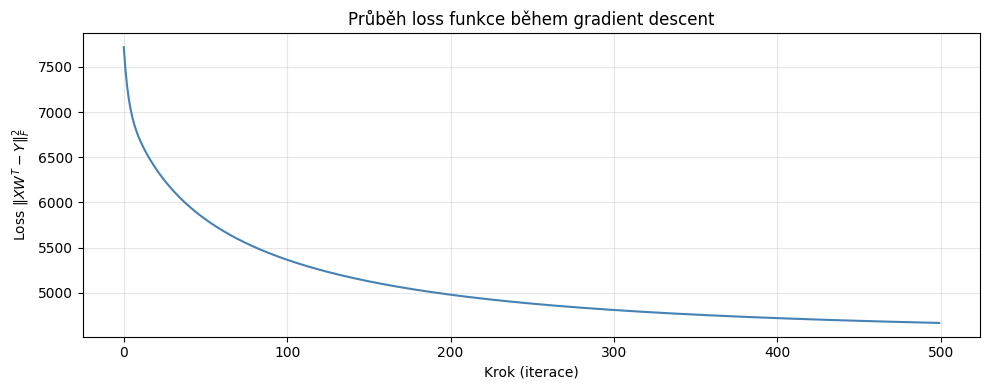

Počáteční loss: 7717.0518
Konečná loss:   4666.0410
Počet kroků:    500


In [13]:
# Vizualizace průběhu loss
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='steelblue', linewidth=1.5)
plt.xlabel('Krok (iterace)')
plt.ylabel('Loss $\\|XW^T - Y\\|_F^2$')
plt.title('Průběh loss funkce během gradient descent')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Počáteční loss: {loss_history[0]:.4f}")
print(f"Konečná loss:   {loss_history[-1]:.4f}")
print(f"Počet kroků:    {len(loss_history)}")

In [14]:
def translate_word(word, src_word2vec, W_T, tgt_matrix, tgt_words, top_k=5):
    """
    Přeloží slovo ze zdrojového do cílového jazyka.

    Parametry:
        word         : vstupní slovo ve zdrojovém jazyce
        src_word2vec : dict {slovo -> np.array} zdrojového jazyka
        W_T          : naučená transformační matice (src_dim, tgt_dim)
        tgt_matrix   : matice embeddingů cílového jazyka (vocab_size, tgt_dim)
        tgt_words    : list slov cílového jazyka (odpovídá řádkům tgt_matrix)
        top_k        : počet nejpodobnějších slov

    Vrátí:
        list dvojic (slovo, kosinová_podobnost), nebo [] pokud slovo není ve slovníku
    """
    if word not in src_word2vec:
        return []

    src_vec = src_word2vec[word].astype(np.float32)
    translated = src_vec @ W_T

    norms = np.linalg.norm(tgt_matrix, axis=1)
    translated_norm = np.linalg.norm(translated)

    if translated_norm == 0:
        return []

    similarities = tgt_matrix @ translated / (norms * translated_norm + 1e-10)
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    return [(tgt_words[i], float(similarities[i])) for i in top_indices]


In [15]:
def evaluate_accuracy(test_pairs, src_word2vec, W_T, tgt_matrix, tgt_words, top_k=5):
    """
    Vyhodnotí přesnost překladu na testovacích dvojicích.

    Vrátí:
        acc1  : accuracy@1 (správný překlad na 1. místě)
        acc5  : accuracy@5 (správný překlad v top 5)
        total : počet vyhodnocených dvojic
    """
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    for src_word, expected_tgt in test_pairs:
        results = translate_word(src_word, src_word2vec, W_T, tgt_matrix, tgt_words, top_k=5)
        if not results:
            continue
        predicted_words = [w for w, _ in results]

        total += 1
        if predicted_words[0] == expected_tgt:
            correct_top1 += 1
        if expected_tgt in predicted_words:
            correct_top5 += 1

    acc1 = correct_top1 / total if total > 0 else 0.0
    acc5 = correct_top5 / total if total > 0 else 0.0

    return acc1, acc5, total


In [16]:
demo_words = ['pes', 'kočka', 'dům', 'auto', 'voda', 'kniha', 'škola', 'Praha']

print("=== Ukázka překladu ===")
print(f"{'CZ slovo':<15} {'Top 5 anglických překladů (podobnost)'}")
print('-' * 70)

for word in demo_words:
    results = translate_word(word, cs_word2vec, W_T, en_matrix, en_words, top_k=5)
    if results:
        top5_str = ', '.join(f"{w} ({s:.3f})" for w, s in results)
        print(f"{word:<15} {top5_str}")
    else:
        print(f"{word:<15} (slovo není ve slovníku)")


=== Ukázka překladu ===
CZ slovo        Top 5 anglických překladů (podobnost)
----------------------------------------------------------------------
pes             dog (0.831), cat (0.702), dogs (0.695), pup (0.686), puppy (0.665)
kočka           cat (0.728), dog (0.706), kitten (0.690), kitty (0.671), raccoon (0.635)
dům             house (0.787), apartment (0.625), home (0.623), houses (0.623), mansion (0.607)
auto            car (0.886), cars (0.739), vehicle (0.717), truck (0.706), automobile (0.668)
voda            water (0.826), seawater (0.635), water.The (0.604), waters (0.602), sediment (0.577)
kniha           book (0.818), books (0.671), book.The (0.606), book- (0.587), book.I (0.577)
škola           school (0.706), education (0.630), college (0.614), university (0.596), kindergarten (0.582)
Praha           europe (0.533), city. (0.526), london (0.515), berlin (0.508), amsterdam (0.508)


In [17]:
print("=== Vyhodnocení na testovací sadě ===")
acc1, acc5, total = evaluate_accuracy(
    test_pairs,
    cs_word2vec,
    W_T,
    en_matrix,
    en_words,
    top_k=5
)

print(f"Testovacích dvojic vyhodnoceno : {total}")
print(f"Accuracy@1                     : {acc1:.4f}  ({acc1*100:.2f} %)")
print(f"Accuracy@5                     : {acc5:.4f}  ({acc5*100:.2f} %)")


=== Vyhodnocení na testovací sadě ===
Testovacích dvojic vyhodnoceno : 1770
Accuracy@1                     : 0.4209  (42.09 %)
Accuracy@5                     : 0.6780  (67.80 %)
